In [ ]:
'''
Lasso Regulisation : 
1. This is a regularization technique used in feature selection using a Shrinkage method also referred to as the 
   penalized regression method.
2. Lasso Regression magnitude of coefficients can be exactly zero.

3. Cost function = Loss + 𝜆 Σ|| w || 

4. Lasso Regulisation does the features in our dataset which is not imp will make it complete zero  

'''

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
dataset = pd.read_csv("houseprice.csv")
dataset.head(10)

,Bedrooms,Bathrooms,Sqft_living,Sqft_lot,Floors,Waterfront,View,Condition,Sqft_above,Sqft_basement,Yr_built,Yr_renovated,Price
0,6,3.00,2400,7420,2.0,0,0,3,2400,0,1991,0,13300000
1,6,3.00,2400,8960,2.0,0,0,3,2400,0,1991,0,12250000
2,4,1.75,2060,9960,1.0,0,0,4,1160,900,1947,0,12250000
3,3,1.00,1460,7500,1.0,0,0,3,1460,0,1952,0,12215000
4,3,1.00,1430,7420,1.5,0,0,4,1010,420,1930,0,11410000
5,4,2.00,1650,7500,1.0,0,0,3,760,890,1951,2013,10850000
6,4,2.75,2220,8580,1.0,0,0,5,1170,1050,1951,0,10150000
7,5,1.50,1990,16200,1.0,0,0,3,1990,0,1960,0,10150000
8,4,2.50,2540,8100,2.0,0,0,3,2540,0,2005,0,9870000
9,3,1.00,1340,5750,1.5,0,0,4,1340,0,1945,0,9800000


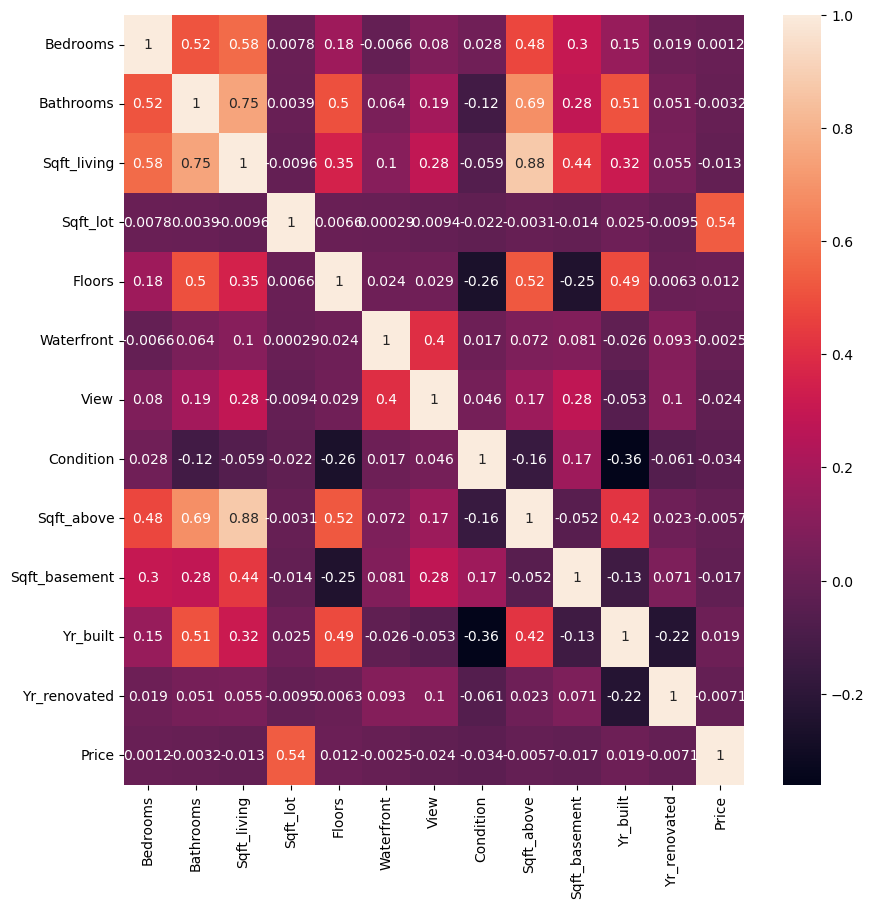

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(data = dataset.corr() , annot = True)
plt.show()

In [9]:
x = dataset.iloc[:,:-1]
y = dataset["Price"]

In [13]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x) , columns=x.columns)
x

,Bedrooms,Bathrooms,Sqft_living,Sqft_lot,Floors,Waterfront,View,Condition,Sqft_above,Sqft_basement,Yr_built,Yr_renovated
0,2.826929,1.149449,0.348534,1.040846,0.936506,-0.087173,-0.305759,-0.629187,0.738595,-0.658681,0.680729,-0.210128
1,2.826929,1.149449,0.348534,1.750457,0.936506,-0.087173,-0.305759,-0.629187,0.738595,-0.658681,0.680729,-0.210128
2,0.676485,-0.473621,-0.021667,2.211243,-0.915427,-0.087173,-0.305759,0.907554,-0.758860,1.374919,-0.817259,-0.210128
3,-0.398737,-1.447464,-0.674963,1.077709,-0.915427,-0.087173,-0.305759,-0.629187,-0.396573,-0.658681,-0.647033,-0.210128
4,-0.398737,-1.447464,-0.707628,1.040846,0.010539,-0.087173,-0.305759,0.907554,-0.940004,0.290333,-1.396027,-0.210128
...,...,...,...,...,...,...,...,...,...,...,...,...
21608,1.751707,-0.149007,-0.522528,-1.062180,0.010539,-0.087173,-0.305759,-0.629187,-0.227505,-0.658681,-1.498163,-0.210128
21609,-1.473959,-1.447464,-1.132271,1.492417,-0.915427,-0.087173,-0.305759,2.444294,-1.145300,-0.206770,-1.089621,-0.210128
21610,-0.398737,-1.447464,-1.066941,1.423299,-0.915427,-0.087173,-0.305759,0.907554,-1.290215,0.199950,-0.987485,-0.210128
21611,-1.473959,-0.473621,-0.729405,-1.217005,0.010539,-0.087173,-0.305759,-0.629187,-1.072843,0.493693,1.361632,-0.210128


In [14]:
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size=0.2 , random_state=42)

In [44]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.metrics import mean_absolute_error , mean_squared_error
import numpy as np

# LinearRegression

In [27]:
lr = LinearRegression()
lr.fit(x_train , y_train)
lr.score(x_test , y_test)*100

29.509744140868555

In [48]:
print(mean_squared_error(y_test , lr.predict(x_test)))
print(mean_absolute_error(y_test , lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test , lr.predict(x_test))))

2438231530317.8745
1157128.3655108337
1561483.7592232185


In [28]:
lr.coef_

array([   8324.20408878,   -9472.26386831,   -6292.16689661,
       1001552.00621194,   22562.56691876,   11225.67680898,
        -25552.04167663,  -48086.54614262,  -15116.25742518,
         15226.0121583 ,   -8017.59294387,  -11476.29845048])

Task was destroyed but it is pending!
task: <Task pending name='Task-409' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/miniconda3/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-410' coro=<Kernel.shell_main() running at /opt/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/miniconda3/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/miniconda3/lib/python3.13/site-packages/matplotlib/transforms.py:195: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-410' coro=<Kernel.shell_main() running at /opt/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


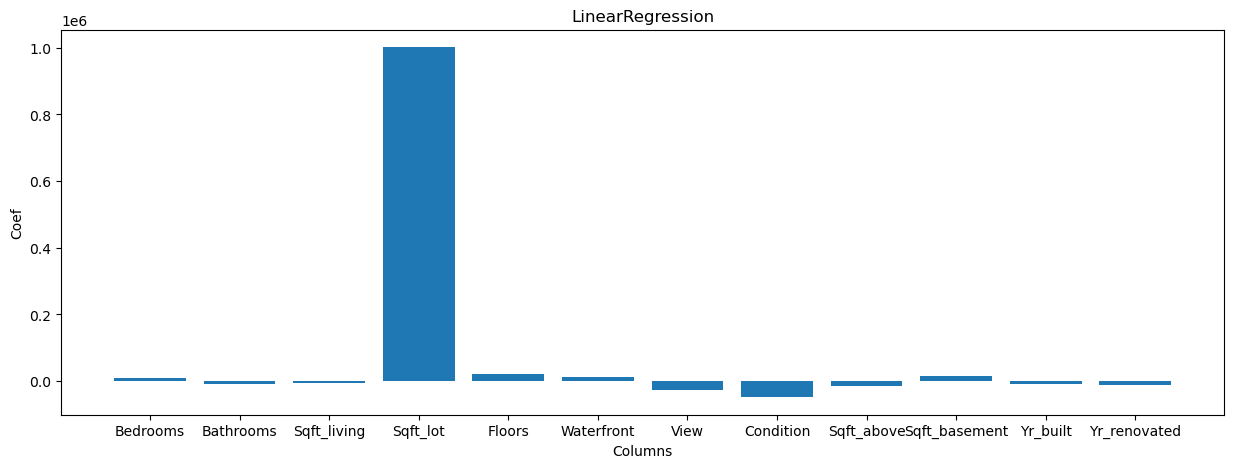

In [29]:
plt.figure(figsize=(15,5))
plt.bar(x.columns , lr.coef_)
plt.title("LinearRegression")
plt.xlabel("Columns")
plt.ylabel("Coef")
plt.show()

# Lasso

In [38]:
la = Lasso(alpha= 0.01)
la.fit(x_train , y_train)
la.score(x_test , y_test)*100

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.970e+14, tolerance: 6.057e+12
  model = cd_fast.enet_coordinate_descent(


29.509744194843577

In [49]:
print(mean_squared_error(y_test , la.predict(x_test)))
print(mean_absolute_error(y_test , la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test , la.predict(x_test))))

2438231528450.8984
1157128.365004477
1561483.7586253975


In [39]:
la.coef_

array([   8324.180506  ,   -9472.23345186,  -20926.9252013 ,
       1001551.99633123,   22562.5250556 ,   11225.65836011,
        -25552.02478299,  -48086.52802574,   -1921.15281606,
         22278.13169141,   -8017.57195874,  -11476.28203412])

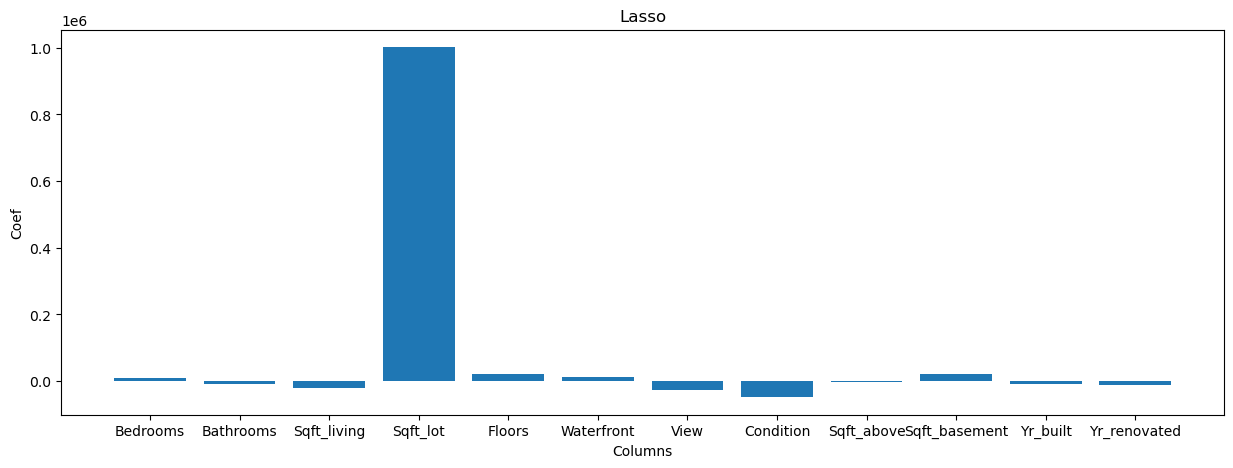

In [40]:
plt.figure(figsize=(15,5))
plt.bar(x.columns , la.coef_)
plt.title("Lasso")
plt.xlabel("Columns")
plt.ylabel("Coef")
plt.show()

# Ridge

In [41]:
ri = Ridge(alpha=10)
ri.fit(x_train , y_train)
ri.score(x_test , y_test)*100

29.510224423424013

In [50]:
print(mean_squared_error(y_test , ri.predict(x_test)))
print(mean_absolute_error(y_test , ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test ,ri.predict(x_test))))

2438214917524.292
1157145.0428781314
1561478.4396604046


In [42]:
ri.coef_

array([   8321.32490236,   -9456.78666107,   -6301.15443324,
       1000966.91382533,   22523.55556193,   11214.37060644,
        -25531.54461533,  -48057.38941672,  -15107.19474294,
         15190.40407873,   -7977.21262852,  -11465.58800295])

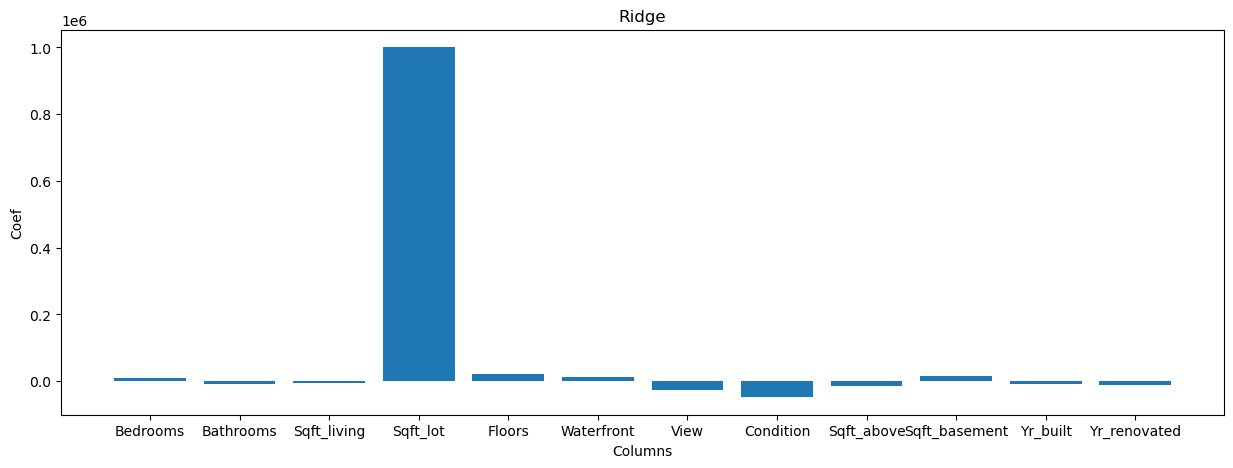

In [43]:
plt.figure(figsize=(15,5))
plt.bar(x.columns , ri.coef_)
plt.title("Ridge")
plt.xlabel("Columns")
plt.ylabel("Coef")
plt.show()

In [51]:
df = pd.DataFrame({"col_name": x.columns ,"LinearRegression":lr.coef_ , "Lasso":la.coef_ , "Ridge":ri.coef_})

In [52]:
df

,col_name,LinearRegression,Lasso,Ridge
0,Bedrooms,8.324204e+03,8.324181e+03,8.321325e+03
1,Bathrooms,-9.472264e+03,-9.472233e+03,-9.456787e+03
2,Sqft_living,-6.292167e+03,-2.092693e+04,-6.301154e+03
3,Sqft_lot,1.001552e+06,1.001552e+06,1.000967e+06
4,Floors,2.256257e+04,2.256253e+04,2.252356e+04
5,Waterfront,1.122568e+04,1.122566e+04,1.121437e+04
6,View,-2.555204e+04,-2.555202e+04,-2.553154e+04
7,Condition,-4.808655e+04,-4.808653e+04,-4.805739e+04
8,Sqft_above,-1.511626e+04,-1.921153e+03,-1.510719e+04
9,Sqft_basement,1.522601e+04,2.227813e+04,1.519040e+04
